In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 면적(제곱미터)과 가격(억 원). 여덟 채의 거래 기록이라고 가정합니다
X = np.array([20, 35, 45, 60, 75, 85, 100, 120], dtype = float)
y = np.array([1.2, 2.0, 2.6, 3.4, 4.1, 4.6, 5.5, 6.4])

print("데이터 개수: ", X.shape, y.shape)
print("면적 평균: ", X.mean(), "/ 가격 평균:", y.mean())

데이터 개수:  (8,) (8,)
면적 평균:  67.5 / 가격 평균: 3.725


In [ ]:
def predict(X, w, b):
  """w는 기울기, b는 절편.
  넘파이 배열을 그대로 넘기면 여덟 채를 한 번에 계산합니다."""
  return w * X + b

print("아직 아무것도 배우지 않은 상태:", predict(X, 0.0, 0.0))

아직 아무것도 배우지 않은 상태: [0. 0. 0. 0. 0. 0. 0. 0.]


In [ ]:
def mse(y_true, y_pred) :
  """평균제곱오차. 오차를 제곱해서 평균을 냅니다"""
  return np.mean((y_true - y_pred) ** 2)

print("w=0, b=0 일 때 손실:", round(mse(y, predict(X, 0.0, 0.0)), 4))
print("w=0.05, b=0.5 일 때 손실:", round(mse(y, predict(X, 0.05, 0.5)), 4))

w=0, b=0 일 때 손실: 16.6175
w=0.05, b=0.5 일 때 손실: 0.03


In [ ]:
# b를 0.2033 에 고정하고 w만 움직입니다. 손실이 그릇 모양으로 나옵니다
for w_try in [ 0.02, 0.03, 0.04, 0.05, 0.0522, 0.06, 0.07, 0.08]:
  print("w =", w_try, "-> 손실", round(mse(y, predict(X, w_try, 0.2033)), 4))

w = 0.02 -> 손실 5.7607
w = 0.03 -> 손실 2.7376
w = 0.04 -> 손실 0.8271
w = 0.05 -> 손실 0.029
w = 0.0522 -> 손실 0.0027
w = 0.06 -> 손실 0.3435
w = 0.07 -> 손실 1.7704
w = 0.08 -> 손실 4.3099


### 경사하강법

In [ ]:
#기울기 계산
def gradients(X, y, w, b) :
  """dw가 양수면 w를 줄여야 손실이 줄고, 음수면 키워야 합니다"""
  n = len(X)
  error = predict(X, w, b) - y
  dw = (2 / n) * np.sum(error * X)
  db = (2 / n) * np.sum(error)
  return dw, db

dw, db = gradients(X, y, 0.0, 0.0)
print("시작 지점의 기울기: dw = ", round(dw, 4), ", db = ", round(db, 4))

시작 지점의 기울기: dw =  -607.875 , db =  -7.45


In [ ]:
#한 번만 고쳐 보기
lr = 0.0001 # 학습률. 기울기를 얼마나 반영할지 정하는 값

w = 0.0 - lr * dw
b = 0.0 - lr * db
print("한 번 고친 뒤: w =", round(w, 6), ", b =", round(b, 6))
print("손실 변화:", round(mse(y, predict(X, 0.0, 0.0)), 4),
      "->", round(mse(y, predict(X, w, b)), 4))

한 번 고친 뒤: w = 0.060788 , b = 0.000745
손실 변화: 16.6175 -> 0.221


### 반복해서 고치기

In [ ]:
# 반복문으로 감싸기
def fit(X, y, lr = 0.0001, steps=2000):
  w, b = 0.0, 0.0
  history= []
  for step in range(steps):
    dw, db = gradients(X, y, w, b)
    w = w - lr * dw
    b = b - lr * db
    history.append(mse(y, predict(X, w, b)))
  return w, b, history

w, b, history = fit(X, y)
for step in [0, 400, 800, 1200, 1600, 1999]:
  print("step", step, "손실", round(history[step], 5))
print("최종 w =", round(w, 4), ", b =", round(b, 4))

step 0 손실 0.22097
step 400 손실 0.00996
step 800 손실 0.00975
step 1200 손실 0.00955
step 1600 손실 0.00936
step 1999 손실 0.00917
최종 w = 0.0545 , b = 0.0148


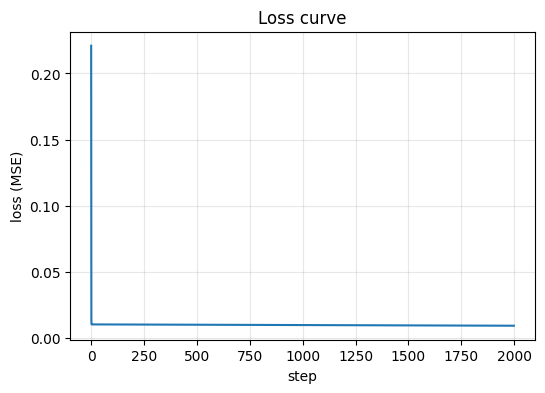

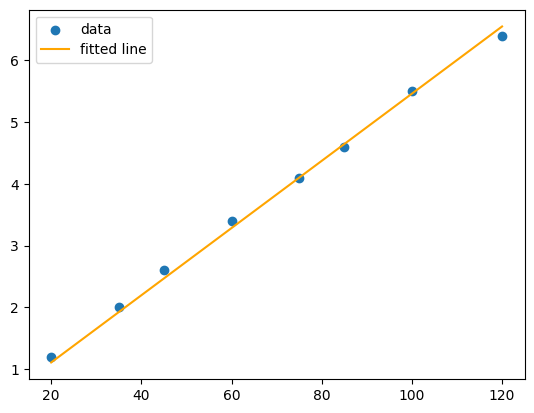

In [ ]:
#손실 곡선 그리기
plt.figure(figsize=(6, 4))
plt.plot(history)
plt.xlabel("step")
plt.ylabel("loss (MSE)")
plt.title("Loss curve")
plt.grid(alpha=0.3)
plt.show()

#결과가 데이터에 얼마나 맞는지도 확인합니다.
plt.scatter(X, y, label="data")
plt.plot(X, predict(X, w, b), color="orange", label = "fitted line")
plt.legend()
plt.show()

### 표준화와 수렴 속도

In [ ]:
# dw가 db보다 80배 컸습니다. 면적이 20에서 120 사이라
# 같은 학습률을 쓰면 b는 거의 움직이지 못합니다.

X_mean, X_std = X.mean(), X.std()
X_scaled = (X - X_mean) / X_std
w_s, b_s, h_s = fit(X_scaled, y, lr=0.05, steps=2000)
print("표준화 후 손실:", round(h_s[-1], 6))

w_back = w_s / X_std
b_back = b_s - w_s * X_mean / X_std
print("되돌린 w =", round(w_back, 4), ", b=", round(b_back, 4))

표준화 후 손실: 0.002745
되돌린 w = 0.0522 , b= 0.2033


In [ ]:
for steps in [10, 20, 50, 100]:
  _,_, h_try = fit(X_scaled, y, lr=0.05, steps = steps)
  print("표준화 후 steps =", steps, "-> 손실", round(h_try[-1], 6))

#표준화 없이 같은 손실에 도달하려면 몇 번이 필요하진 확인합니다
for steps in [2000, 50000, 200000]:
  _,_, h_raw = fit(X, y, lr=0.0001, steps = steps)
  print("표준화 없이 steps =", steps, "-> 손실", round(h_raw[-1], 6))

표준화 후 steps = 10 -> 손실 2.022711
표준화 후 steps = 20 -> 손실 0.248325
표준화 후 steps = 50 -> 손실 0.003186
표준화 후 steps = 100 -> 손실 0.002745
표준화 없이 steps = 2000 -> 손실 0.009169
표준화 없이 steps = 50000 -> 손실 0.002944
표준화 없이 steps = 200000 -> 손실 0.002745
